# Tutorial: xarray, Dask, and `cubo`

This notebook is a compact tutorial for **medium-resolution Earth Observation (EO)** workflows focused on **climate resilience** and **risk monitoring**.

It uses a single user-facing API — [`cubo`](https://cubo.readthedocs.io/) — to show how the same workflow can target:

- **Google Earth Engine** with `gee=True`
- **STAC catalogs** (Planetary Computer by default)
- **alternative STAC endpoints** with `stac="..."`


## Learning goals

By the end of this notebook, participants should be able to:

1. explain why **xarray** is useful for EO data cubes,
2. describe how **Dask** enables chunked and lazy processing,
3. make a basic API request with **`cubo.create(...)`**,
4. inspect a Dask-backed `xarray.DataArray`,
5. run a simple Africa vegetation example and an Asia coastal example,
6. adapt the same notebook to a different backend or endpoint.


## 1. Environment setup

Install the packages you need. For Google Earth Engine access, use the `ee` extra:

```bash
pip install "cubo[ee]" xarray dask matplotlib notebook
```

If you only want STAC access, `pip install cubo xarray dask matplotlib` is usually enough.


In [4]:
import cubo
import xarray as xr
import numpy as np
import matplotlib.pyplot as plt
import dask

# Optional: for the GEE examples
import ee


## 2. Earth Engine authentication

Run this once in a fresh environment if needed:

```python
ee.Authenticate()
```

Then initialize the high-volume endpoint used in the current `cubo` tutorial:

```python
ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")
```


In [6]:
ee.Authenticate()
ee.Initialize(project="ee-kizarzakir")

In [ ]:
# Uncomment if needed in a new environment:
# ee.Authenticate()
# ee.Initialize(opt_url="https://earthengine-highvolume.googleapis.com")


## 3. Why xarray + Dask?

`cubo.create(...)` returns an **`xarray.DataArray`**. That matters because you immediately get:

- labeled dimensions like `time`, `band`, `y`, and `x`,
- coordinate-aware selection with `.sel(...)` and `.isel(...)`,
- reductions like `.mean(...)`, `.median(...)`, `.groupby(...)`,
- optional **Dask-backed** lazy execution for larger-than-memory workflows.

A good beginner mental model is:

**API call → xarray object → lazy chunked operations → compute only when needed**


In [2]:
toy = xr.DataArray(
    np.random.rand(6, 3, 32, 32),
    dims=("time", "band", "y", "x"),
    coords={
        "time": np.arange(6),
        "band": ["B1", "B2", "B3"]
    },
    name="toy_cube"
).chunk({"time": 2, "band": 1, "y": 32, "x": 32})

toy


<xarray.DataArray 'toy_cube' (time: 6, band: 3, y: 32, x: 32)> Size: 147kB
dask.array<xarray-<this-array>, shape=(6, 3, 32, 32), dtype=float64, chunksize=(2, 1, 32, 32), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 48B 0 1 2 3 4 5
  * band     (band) <U2 24B 'B1' 'B2' 'B3'
Dimensions without coordinates: y, x

In [3]:
print("Dask-backed:", dask.is_dask_collection(toy.data))
print("Chunk structure:", toy.chunks)

lazy_result = toy.mean(("x", "y"))
lazy_result


Dask-backed: True
Chunk structure: ((2, 2, 2), (1, 1, 1), (32,), (32,))


<xarray.DataArray 'toy_cube' (time: 6, band: 3)> Size: 144B
dask.array<mean_agg-aggregate, shape=(6, 3), dtype=float64, chunksize=(2, 1), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) int64 48B 0 1 2 3 4 5
  * band     (band) <U2 24B 'B1' 'B2' 'B3'

The result above is still **lazy**. Nothing expensive happens until you ask for values explicitly with `.compute()`, `.load()`, plotting, or writing to disk.


In [4]:
lazy_result.compute()


<xarray.DataArray 'toy_cube' (time: 6, band: 3)> Size: 144B
array([[0.49619101, 0.49386056, 0.49531824],
       [0.49947857, 0.50544716, 0.48302337],
       [0.4990598 , 0.5003907 , 0.49632866],
       [0.48857915, 0.48821215, 0.50259648],
       [0.49552917, 0.49072622, 0.48647535],
       [0.50533131, 0.48938618, 0.49686431]])
Coordinates:
  * time     (time) int64 48B 0 1 2 3 4 5
  * band     (band) <U2 24B 'B1' 'B2' 'B3'

## 4. Common `cubo.create(...)` pattern

Most examples follow the same structure:

```python
cube = cubo.create(
    lat=...,
    lon=...,
    collection="...",
    bands=[...],
    start_date="YYYY-MM-DD",
    end_date="YYYY-MM-DD",
    edge_size=...,
    resolution=...,
    gee=True,              # optional
    stac="https://...",    # optional
)
```

Core decisions:
- **where**: `lat`, `lon`
- **what**: `collection`, `bands`
- **when**: `start_date`, `end_date`
- **how much**: `edge_size`, `resolution`
- **which backend**: default STAC, custom STAC, or `gee=True`


## 5. Example A — Africa vegetation monitoring with MODIS NDVI/EVI

A practical climate resilience example is to extract a small cube over the **Horn of Africa** or the **Sahel** and compute a time series of vegetation conditions.

This example uses the Google Earth Engine collection:

- `MODIS/061/MOD13Q1`
- 250 m pixels
- 16-day cadence
- bands such as `NDVI` and `EVI`

### Suggested study point
- Ethiopia / Horn of Africa: `lat=8.98`, `lon=39.79`


In [7]:
africa_cube = cubo.create(
    lat=8.98,
    lon=39.79,
    collection="MODIS/061/MOD13Q1",
    bands=["NDVI", "EVI"],
    start_date="2021-01-01",
    end_date="2021-12-31",
    edge_size=64,
    resolution=250,
    gee=True,
)

africa_cube


<xarray.DataArray 'MODIS/061/MOD13Q1' (time: 23, band: 2, y: 64, x: 64)> Size: 754kB
dask.array<transpose, shape=(23, 2, 64, 64), dtype=float32, chunksize=(23, 1, 64, 64), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 184B 2021-01-01 ... 2021...
  * band                       (band) object 16B 'NDVI' 'EVI'
  * y                          (y) float64 512B 9.849e+05 ... 1.001e+06
  * x                          (x) float64 512B 5.789e+05 ... 5.946e+05
    cubo:distance_from_center  (y, x) float64 33kB 1.119e+04 ... 1.108e+04
Attributes:
    collection:           MODIS/061/MOD13Q1
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32637
    resolution:           250
    edge_size:            64
    edge_size_m:          16000
    central_lat:          8.98
    central_lon:          39.79
    central_y:            992734.4857423949
    central_x:            586839.4490246739
    time_coverage_start:  2021-01-01
    time_coverage_end:    2021-12-31

### Inspect the object

Notice the labeled dimensions and the Dask-backed representation.


In [8]:
print(africa_cube.dims)
print(africa_cube.coords)
print("Chunks:", africa_cube.chunks)


('time', 'band', 'y', 'x')
Coordinates:
  * time                       (time) datetime64[ns] 184B 2021-01-01 ... 2021...
  * band                       (band) object 16B 'NDVI' 'EVI'
  * y                          (y) float64 512B 9.849e+05 ... 1.001e+06
  * x                          (x) float64 512B 5.789e+05 ... 5.946e+05
    cubo:distance_from_center  (y, x) float64 33kB 1.119e+04 ... 1.108e+04
Chunks: ((23,), (1, 1), (64,), (64,))


### Important note on scale factors

For MODIS vegetation indices, values are typically stored with a **scale factor**. A common first step is to convert them to approximately physical units.

For MOD13Q1, a simple teaching example is:

```python
africa_scaled = africa_cube / 10000.0
```

For production work, always verify the product documentation and quality flags.


In [9]:
africa_scaled = africa_cube / 10000.0

africa_ts = (
    africa_scaled
    .sel(band="NDVI")
    .mean(("x", "y"))
)

africa_ts


<xarray.DataArray 'MODIS/061/MOD13Q1' (time: 23)> Size: 92B
dask.array<mean_agg-aggregate, shape=(23,), dtype=float32, chunksize=(23,), chunktype=numpy.ndarray>
Coordinates:
  * time     (time) datetime64[ns] 184B 2021-01-01 2021-01-17 ... 2021-12-19
    band     <U4 16B 'NDVI'
Attributes:
    collection:           MODIS/061/MOD13Q1
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32637
    resolution:           250
    edge_size:            64
    edge_size_m:          16000
    central_lat:          8.98
    central_lon:          39.79
    central_y:            992734.4857423949
    central_x:            586839.4490246739
    time_coverage_start:  2021-01-01
    time_coverage_end:    2021-12-31

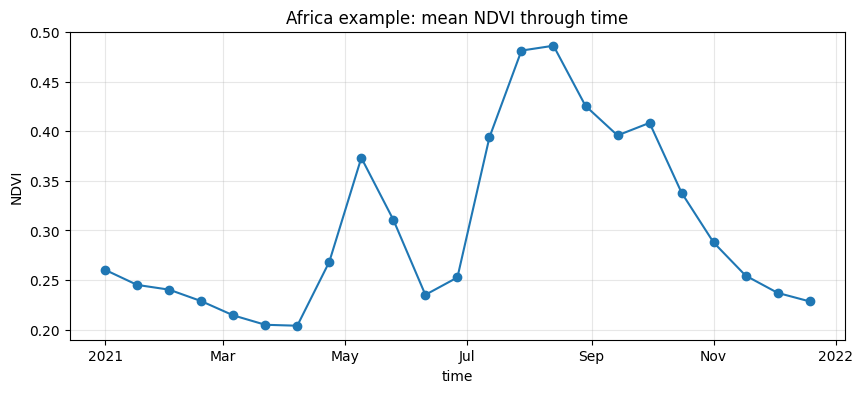

In [10]:
africa_ts.compute().plot(marker="o", figsize=(10, 4))
plt.title("Africa example: mean NDVI through time")
plt.ylabel("NDVI")
plt.grid(True, alpha=0.3)
plt.show()


### Discussion points

- Why is the result still manageable even if the source is remote?
- Which step is lazy, and which step forces execution?
- How would you compare this year against a baseline climatology?
- Where would QA masking fit into the workflow?


## 6. Example B — Asia coastal monitoring with Sentinel-3 OLCI

For Asia, a simple medium-resolution example is to look at a coastal or delta region and build an RGB quicklook or a band composite from **Sentinel-3 OLCI**.

This example uses:

- `COPERNICUS/S3/OLCI`
- 21 spectral bands
- 300 m spatial resolution
- roughly 2-day revisit

### Suggested study point
- Ganges–Brahmaputra delta / coastal Bangladesh: `lat=22.20`, `lon=90.70`


In [11]:
asia_cube = cubo.create(
    lat=22.20,
    lon=90.70,
    collection="COPERNICUS/S3/OLCI",
    bands=["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"],
    start_date="2024-01-01",
    end_date="2024-01-10",
    edge_size=96,
    resolution=300,
    gee=True,
)

asia_cube


<xarray.DataArray 'COPERNICUS/S3/OLCI' (time: 10, band: 3, y: 96, x: 96)> Size: 1MB
dask.array<transpose, shape=(10, 3, 96, 96), dtype=float32, chunksize=(10, 1, 96, 96), chunktype=numpy.ndarray>
Coordinates:
  * time                       (time) datetime64[ns] 80B 2024-01-01T03:53:52 ...
  * band                       (band) object 24B 'Oa08_radiance' ... 'Oa04_ra...
  * y                          (y) float64 768B 2.442e+06 ... 2.471e+06
  * x                          (x) float64 768B 2.486e+05 ... 2.771e+05
    cubo:distance_from_center  (y, x) float64 74kB 2.025e+04 ... 2.005e+04
Attributes:
    collection:           COPERNICUS/S3/OLCI
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32646
    resolution:           300
    edge_size:            96
    edge_size_m:          28800
    central_lat:          22.2
    central_lon:          90.7
    central_y:            2456763.3429751364
    central_x:            262880.5766215245
    time_coverage_start:  2024-01-01
    time_coverage_end:    2024-01-10

### Build a simple median RGB-style quicklook

The Earth Engine catalog example applies band-specific scale factors before visualization. For a notebook tutorial, it is enough to show the idea and note that **visualization scaling is dataset-specific**.


In [12]:
asia_rgb = asia_cube.median("time")

asia_rgb


<xarray.DataArray 'COPERNICUS/S3/OLCI' (band: 3, y: 96, x: 96)> Size: 111kB
dask.array<nanmedian, shape=(3, 96, 96), dtype=float32, chunksize=(1, 96, 96), chunktype=numpy.ndarray>
Coordinates:
  * band                       (band) object 24B 'Oa08_radiance' ... 'Oa04_ra...
  * y                          (y) float64 768B 2.442e+06 ... 2.471e+06
  * x                          (x) float64 768B 2.486e+05 ... 2.771e+05
    cubo:distance_from_center  (y, x) float64 74kB 2.025e+04 ... 2.005e+04
Attributes:
    collection:           COPERNICUS/S3/OLCI
    stac:                 https://earthengine-stac.storage.googleapis.com/cat...
    epsg:                 32646
    resolution:           300
    edge_size:            96
    edge_size_m:          28800
    central_lat:          22.2
    central_lon:          90.7
    central_y:            2456763.3429751364
    central_x:            262880.5766215245
    time_coverage_start:  2024-01-01
    time_coverage_end:    2024-01-10

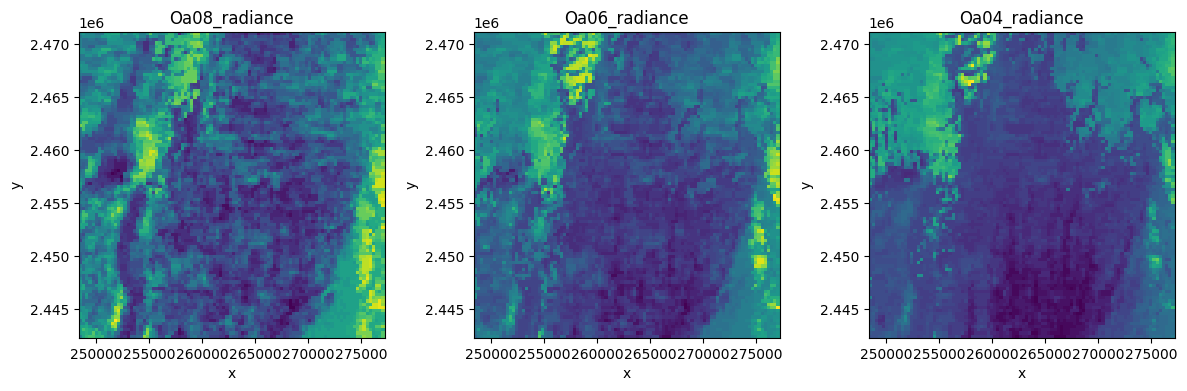

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for ax, band in zip(axes, ["Oa08_radiance", "Oa06_radiance", "Oa04_radiance"]):
    asia_rgb.sel(band=band).compute().plot(ax=ax, add_colorbar=False)
    ax.set_title(band)
    ax.set_aspect("equal")
plt.tight_layout()
plt.show()


### Discussion

- Why is Sentinel-3 a good match for regional coastal monitoring?
- Which bands would you choose for turbidity, vegetation, or water color?
- What changes when you move from a quicklook to a quantitative indicator?


## 7. Optional: test a STAC endpoint with the same API

One nice feature of `cubo` is that the user-facing call stays almost the same when you switch from GEE to a STAC endpoint.

The documentation shows an Element84 Earth Search example like this:


In [43]:

da = cubo.create(
    lat=4.31,
    lon=-76.2,
    collection="sentinel-2-l2a",
    bands=["red", "green", "blue"],
    start_date="2020-01-01",
    end_date="2020-06-01",
    edge_size=128,
    resolution=10,
    stac="https://earth-search.aws.element84.com/v1"
)
da

print("da dims:", da.dims)
print("da sizes:", dict(da.sizes))
da

da dims: ('time', 'band', 'y', 'x')
da sizes: {'time': 62, 'band': 3, 'y': 128, 'x': 128}


<xarray.DataArray 'sentinel-2-l2a' (time: 62, band: 3, y: 128, x: 128)> Size: 24MB
dask.array<fetch_raster_window, shape=(62, 3, 128, 128), dtype=float64, chunksize=(1, 1, 128, 128), chunktype=numpy.ndarray>
Coordinates: (12/54)
  * time                                     (time) datetime64[ns] 496B 2020-...
    id                                       (time) <U24 6kB 'S2A_18NUK_20200...
    view:sun_elevation                       (time) float64 496B 55.67 ... 63.38
    s2:medium_proba_clouds_percentage        (time) float64 496B 16.35 ... 16.06
    s2:water_percentage                      (time) object 496B 0.059412 ... ...
    s2:vegetation_percentage                 (time) object 496B 20.609057 ......
    ...                                       ...
    proj:code                                <U10 40B 'EPSG:32618'
    constellation                            <U10 40B 'sentinel-2'
    gsd                                      int64 8B 10
    proj:transform                           object 8B {0, 300000, 500040, 10...
    proj:shape                               object 8B {10980}
    epsg                                     int64 8B 32618
Attributes:
    collection:           sentinel-2-l2a
    stac:                 https://earth-search.aws.element84.com/v1
    epsg:                 32618
    resolution:           10
    edge_size:            128
    edge_size_m:          1280
    central_lat:          4.31
    central_lon:          -76.2
    central_y:            476498.32356558647
    central_x:            366835.4548862558
    time_coverage_start:  2020-01-01
    time_coverage_end:    2020-06-01

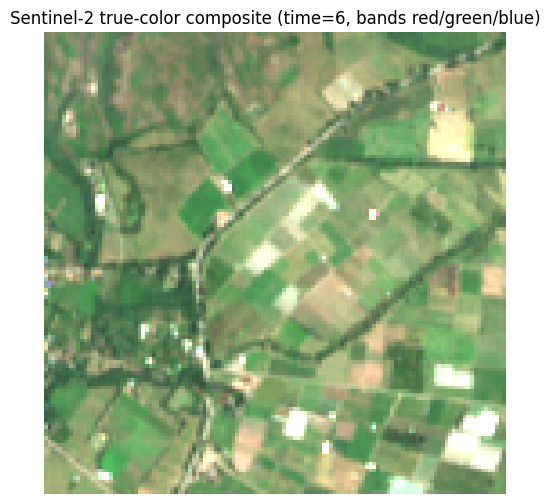

In [ ]:
# Visualize true-color RGB image 
band_names = [str(b) for b in da.band.values] if "band" in da.dims else []
rgb_bands = band_names[:3]

rgb = da.sel(band=rgb_bands).isel(time=3).compute()

# Stretch for display
rgb = rgb / rgb.quantile(0.98)
rgb = rgb.clip(0, 1)

plt.figure(figsize=(6, 6))
plt.imshow(np.transpose(rgb.values, (1, 2, 0)))
plt.title(f"Sentinel-2 true-color composite (time=3, bands {'/'.join(rgb_bands)})")
plt.axis("off")
plt.show()

This is a good section for workshop participants to experiment with:

- swapping the endpoint,
- changing the collection,
- changing bands and dates,
- comparing how the returned `xarray` object looks.


### Common STAC end-points: 

1. OpenLandMap
2. EMCWF STAC
3. [CDSE STAC](https://github.com/eu-cdse/notebook-samples/blob/main/geo/stac_ndvi.ipynb)

## 8. Minimal checklist for good Dask practice

When this notebook becomes a real workflow, the biggest beginner mistakes are usually about chunking and forcing computation too early.

### Good defaults for teaching
- keep the spatial subset small,
- start with a short date range,
- inspect `.chunks`,
- chain xarray operations before `.compute()`.

### Watch out for
- calling `.compute()` too soon,
- plotting very large arrays too early,
- using chunks that are too tiny,
- forgetting product-specific scaling or QA masks.


## 9. Wrap-up

Key message:

> **Use `cubo` as the single entry point, `xarray` as the analysis model, and Dask as the scaling layer.**

That gives one consistent mental model:
1. request a remote EO cube,
2. inspect dimensions and chunks,
3. perform labeled operations lazily,
4. compute only for the final result.
